# GAM Pipeline — Nested Resampling, Full-Data Retuning, and Manifest Export

This notebook compares multiple GAM variants on a shared prepared dataset, uses nested resampling to estimate how robustly the tuning process generalizes, identifies the variant with the best generalization, and then applies that same tuning process on all rows before refitting the exported final GAM on all available data.<br>
**Workflow summary:** track 1 compares the candidate GAM variants with nested resampling to obtain an unbiased performance estimate for the tuning procedure, identify the variant with the best generalization, and decide which variant should be carried forward into further analysis; track 2 reruns that tuning procedure for the winning variant on the full filtered dataset, identifies the best full-data hyperparameter configuration, refits the final GAM on all rows with that configuration, and then exports the manifest-driven artifact set.


## 1. Imports and Configuration
**Purpose:** Load the local helper modules, GAM libraries, and run-scoped configuration that define this comparison run.<br>
**Inputs:** local `src/` package path, prepared-data CSV path, CV/tuning hyperparameters, and export directories.<br>
**Outputs:** imported modelling libraries, resolved paths, and output folders for plots/tables/models.<br>
**How to Verify:** confirm the printed run metadata, `DATA_PATH`, `SAVE_DIR`, and nested-CV settings before any data-dependent logic runs.


In [22]:
# Ensure the notebook can import local helper modules even when it is launched
# from a nested working directory inside the repository.
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src_dir = candidate / "src"
    if (src_dir / "data_modelling").exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise RuntimeError("Could not locate repo src/ directory for notebook imports.")

In [23]:
# Core libraries
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

import optuna
from pygam import LinearGAM, GammaGAM, s, f

from data_modelling.common_metrics import regression_metrics, rmse, to_original_scale
from data_modelling.prepared_data import (
    load_prepared_data,
    prepare_dual_target_model_data,
)
from data_modelling.training_outputs import (
    build_oof_frame,
    build_oof_metrics_df,
    build_run_manifest,
    summarize_nested_cv,
    write_manifest,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

MODEL_ID = "gam"
RUN_NAME = "sweep_large_30ep_1seed_MI_corrected"
DATA_RUN_NAME = "sweep_large_30ep_1seed_MI_corrected"
OUTPUT_RUN_NAME = "sweep_large_30ep_1seed_MI_corrected"
PREPARED_TARGET_COL = "ml_ade"
DATA_PATH = (
    Path("../../results/interpretable_model/prepared_data")
    / DATA_RUN_NAME
    / f"prepared_data_{PREPARED_TARGET_COL}.csv"
)
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log' or 'ml_ade'

RANDOM_STATE = 42
k_outer_fold = 3  # 5
k_inner_fold = 3
N_OPTUNA_TRIALS = 15  # 40
POOR_WELL_QUANTILE = 0.20
MIN_SPLINES = 10
MAX_SPLINES = 50
MIN_SPLINE_ORDER = 3
MAX_SPLINE_ORDER = 4
MIN_LAM = 1e-3
MAX_LAM = 1e3
TUNING_METRIC = "rmse"

SAVE_DIR = Path("../../results/interpretable_model") / MODEL_ID / OUTPUT_RUN_NAME
PLOTS_DIR = SAVE_DIR / "plots"
TABLES_DIR = SAVE_DIR / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports and configuration loaded.")
print(f"Data run: {DATA_RUN_NAME}")
print(f"Output run: {OUTPUT_RUN_NAME}")
print(f"Model ID: {MODEL_ID}")
print("Interpretable model: GAM")
print(f"DATA_PATH: {DATA_PATH}")
print(f"SAVE_DIR:  {SAVE_DIR.resolve()}")
print(
    "Nested CV: "
    f"outer={k_outer_fold}, inner={k_inner_fold}, optuna_trials={N_OPTUNA_TRIALS}"
)

Imports and configuration loaded.
Data run: sweep_large_30ep_1seed_MI_corrected
Output run: sweep_large_30ep_1seed_MI_corrected
Model ID: gam
Interpretable model: GAM
DATA_PATH: ../../results/interpretable_model/prepared_data/sweep_large_30ep_1seed_MI_corrected/prepared_data_ml_ade.csv
SAVE_DIR:  <repo>/results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected
Nested CV: outer=3, inner=3, optuna_trials=15


## 2. Load Prepared Data and Resolve Targets
**Purpose:** Load the prepared table once and derive a single feature matrix plus both raw/log target views for variant comparison.<br>
**Inputs:** `DATA_PATH`, optional `TARGET_COL` override, and the default target name.<br>
**Outputs:** `model_df`, `X`, `y_raw`, `y_log`, `feature_cols`, and the resolved raw/log target column names.<br>
**How to Verify:** confirm the printed target names, row count, feature count, and array shapes immediately after preparation.


In [24]:
# The preparation helper returns one filtered modelling frame plus both raw/log targets
# so every GAM variant can be compared on exactly the same rows and features.
df = load_prepared_data(DATA_PATH, display_fn=display)

prepared = prepare_dual_target_model_data(
    df,
    target_col=TARGET_COL,
    default_target="ml_ade",
)
raw_target_col = prepared["raw_target_col"]
log_target_col = prepared["log_target_col"]
target_col = prepared["target_col"]
feature_cols = prepared["feature_cols"]
identity_cols = prepared["identity_cols"]
model_df = prepared["model_df"]
X = prepared["X"]
y_raw = prepared["y_raw"]
y_log = prepared["y_log"]
row_ids = prepared["row_ids"]
n_features = prepared["n_features"]

model_setting_cols = prepared["model_setting_cols"]
discrete_feature_indices = frozenset(
    i for i, col in enumerate(feature_cols) if col in model_setting_cols
)
print(f"Model settings (factor terms): {[feature_cols[i] for i in sorted(discrete_feature_indices)]}")
print(f"Discrete feature indices: {sorted(discrete_feature_indices)}")

print(f"Raw target column: {raw_target_col}")
print(f"Log target column: {log_target_col}")
print(f"Primary target column for nested resampling: {target_col}")
print(f"Identity columns preserved: {identity_cols}")
print(f"Number of features: {len(feature_cols)}")
print(f"Rows available for modeling: {len(model_df)}")
print(f"Feature matrix shape: {X.shape}")
print(f"Raw target shape: {y_raw.shape}")
print(f"Log target shape: {y_log.shape}")

Dataset shape: (36947, 12)
Columns:
['run_name', 'eval_csv_name', 'data_idx', 'max_speed', 'std_speed', 'heading_change_per_sec', 'min_neighbor_distance', 'mean_acceleration', 'attention_radius_m', 'history_sec', 'prediction_sec', 'ml_ade_log']


,run_name,eval_csv_name,data_idx,max_speed,std_speed,heading_change_per_sec,min_neighbor_distance,mean_acceleration,attention_radius_m,history_sec,prediction_sec,ml_ade_log
0,sweep_large_1seed_seed123_h1p0_p2p0_r0p25_30ep...,eval_epoch_30_combined.csv,354,1.563803,0.132346,0.375624,0.857756,1.173304e-01,2.5,1.0,2.0,0.147753
1,sweep_large_1seed_seed123_h1p0_p2p0_r0p25_30ep...,eval_epoch_30_combined.csv,642,1.467800,0.001086,0.032855,0.655952,6.670220e-14,2.5,1.0,2.0,0.037634
2,sweep_large_1seed_seed123_h1p0_p2p0_r0p25_30ep...,eval_epoch_30_combined.csv,541,1.872800,0.191731,1.859537,1.942528,-1.534201e-01,2.5,1.0,2.0,0.144703
3,sweep_large_1seed_seed123_h1p0_p2p0_r0p25_30ep...,eval_epoch_30_combined.csv,272,1.287559,0.006926,1.416332,0.782366,-5.026471e-03,2.5,1.0,2.0,0.057175
4,sweep_large_1seed_seed123_h1p0_p2p0_r0p25_30ep...,eval_epoch_30_combined.csv,893,0.174011,0.057202,3.197176,0.643476,4.821808e-02,2.5,1.0,2.0,0.186827


Model settings included as features: ['attention_radius_m', 'history_sec', 'prediction_sec']
Model settings (factor terms): ['attention_radius_m', 'history_sec', 'prediction_sec']
Discrete feature indices: [5, 6, 7]
Raw target column: ml_ade
Log target column: ml_ade_log
Primary target column for nested resampling: ml_ade_log
Identity columns preserved: ['run_name', 'eval_csv_name', 'data_idx']
Number of features: 8
Rows available for modeling: 36947
Feature matrix shape: (36947, 8)
Raw target shape: (36947,)
Log target shape: (36947,)


## 3. Shared Helpers
**Purpose:** Define the reusable building blocks for fitting, tuning, and exporting GAM variants.<br>
**Inputs:** shared feature matrix shape, scaling assumptions, Optuna search ranges, and target-mode metadata.<br>
**Outputs:** helper functions that build GAM terms, fit models, evaluate folds, tune variants, and allocate artifact directories.<br>
**How to Verify:** read each helper in order and confirm that scaling happens before fitting and inverse-scaling happens before metrics are computed.


In [25]:
# These helpers make the shared GAM workflow explicit: build terms, fit one model,
# evaluate a parameter set, tune via inner CV, then allocate per-variant artifact dirs.
def build_gam_terms(n_features, n_splines, spline_order, discrete_indices=()):
    discrete_set = frozenset(discrete_indices)
    def _make_term(idx):
        if idx in discrete_set:
            return f(idx)
        return s(idx, n_splines=n_splines, spline_order=spline_order)
    terms = _make_term(0)
    for idx in range(1, n_features):
        terms += _make_term(idx)
    return terms


def fit_gam_model(model_kind, X_train_scaled, y_train, params, discrete_indices=()):
    terms = build_gam_terms(
        n_features=X_train_scaled.shape[1],
        n_splines=int(params["n_splines"]),
        spline_order=int(params["spline_order"]),
        discrete_indices=discrete_indices,
    )
    if model_kind == "linear":
        model = LinearGAM(terms, lam=float(params["lam"]))
    elif model_kind == "gamma":
        model = GammaGAM(terms, lam=float(params["lam"]))
    else:
        raise ValueError(f"Unsupported model_kind={model_kind}")

    model.fit(X_train_scaled, y_train)
    return model


def evaluate_variant_cv(
    X_values, y_values, *, model_kind, target_mode, params, seed, variant_name, discrete_indices=()
):
    cv = KFold(n_splits=k_inner_fold, shuffle=True, random_state=seed)
    fold_rows = []

    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_values), start=1):
        X_train = X_values[train_idx]
        X_valid = X_values[valid_idx]
        y_train = y_values[train_idx]
        y_valid = y_values[valid_idx]

        # Fit the scaler on the training split only so validation metrics reflect a
        # realistic deployment-time preprocessing pipeline.
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)

        model = fit_gam_model(model_kind, X_train_scaled, y_train, params, discrete_indices=discrete_indices)
        y_pred = model.predict(X_valid_scaled)
        y_valid_orig = to_original_scale(y_valid, target_mode=target_mode)
        y_pred_orig = to_original_scale(y_pred, target_mode=target_mode)
        metrics = regression_metrics(y_valid_orig, y_pred_orig)

        fold_rows.append(
            {
                "variant_name": variant_name,
                "fold": fold_idx,
                "R²": metrics["R²"],
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
            }
        )

    fold_metrics_df = pd.DataFrame(fold_rows)
    summary = {
        "cv_r2_mean": float(fold_metrics_df["R²"].mean()),
        "cv_r2_std": float(fold_metrics_df["R²"].std(ddof=1)),
        "cv_mae_mean": float(fold_metrics_df["MAE"].mean()),
        "cv_mae_std": float(fold_metrics_df["MAE"].std(ddof=1)),
        "cv_rmse_mean": float(fold_metrics_df["RMSE"].mean()),
        "cv_rmse_std": float(fold_metrics_df["RMSE"].std(ddof=1)),
    }

    return {
        "fold_metrics_df": fold_metrics_df,
        "summary": summary,
    }


def run_gam_optuna_tuning(
    X_values, y_values, *, model_kind, target_mode, seed, tuning_scope, variant_name, discrete_indices=()
):
    trial_rows = []

    def objective(trial):
        params = {
            "n_splines": trial.suggest_int("n_splines", MIN_SPLINES, MAX_SPLINES),
            "spline_order": trial.suggest_int(
                "spline_order", MIN_SPLINE_ORDER, MAX_SPLINE_ORDER
            ),
            "lam": trial.suggest_float("lam", MIN_LAM, MAX_LAM, log=True),
        }

        inner_cv = KFold(n_splits=k_inner_fold, shuffle=True, random_state=seed)
        fold_rmses = []

        for inner_train_idx, inner_valid_idx in inner_cv.split(X_values):
            X_inner_train = X_values[inner_train_idx]
            X_inner_valid = X_values[inner_valid_idx]
            y_inner_train = y_values[inner_train_idx]
            y_inner_valid = y_values[inner_valid_idx]

            scaler = StandardScaler()
            X_inner_train_scaled = scaler.fit_transform(X_inner_train)
            X_inner_valid_scaled = scaler.transform(X_inner_valid)

            try:
                model = fit_gam_model(
                    model_kind, X_inner_train_scaled, y_inner_train, params, discrete_indices=discrete_indices
                )
                y_inner_pred = model.predict(X_inner_valid_scaled)
                # Convert back to the raw target scale before ranking trials so raw- and
                # log-target variants compete on the same interpretable error metric.
                y_inner_valid_orig = to_original_scale(
                    y_inner_valid, target_mode=target_mode
                )
                y_inner_pred_orig = to_original_scale(
                    y_inner_pred, target_mode=target_mode
                )
                fold_rmses.append(rmse(y_inner_valid_orig, y_inner_pred_orig))
            except Exception:
                # Invalid parameter combinations should lose the trial rather than abort the
                # whole search, so assign an infinite CV RMSE and continue.
                fold_rmses.append(float("inf"))

        mean_cv_rmse = float(np.mean(fold_rmses))
        row = {
            "variant_name": variant_name,
            "tuning_scope": tuning_scope,
            "trial_number": trial.number,
            "mean_cv_rmse": mean_cv_rmse,
            "n_splines": int(params["n_splines"]),
            "spline_order": int(params["spline_order"]),
            "lam": float(params["lam"]),
        }
        trial_rows.append(row)
        return mean_cv_rmse

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

    trial_results_df = (
        pd.DataFrame(trial_rows).sort_values("mean_cv_rmse").reset_index(drop=True)
    )
    best_params = {
        "n_splines": int(study.best_params["n_splines"]),
        "spline_order": int(study.best_params["spline_order"]),
        "lam": float(study.best_params["lam"]),
    }
    best_cv_rmse = float(study.best_value)

    print(
        f"{variant_name} | {tuning_scope} tuning complete | "
        f"best_cv_rmse={best_cv_rmse:.6f}"
    )

    return {
        "best_params": best_params,
        "best_cv_rmse": best_cv_rmse,
        "trial_results_df": trial_results_df,
    }


def get_artifact_dirs(model_id):
    save_dir = Path("../../results/interpretable_model") / model_id / OUTPUT_RUN_NAME
    plots_dir = save_dir / "plots"
    tables_dir = save_dir / "tables"
    plots_dir.mkdir(parents=True, exist_ok=True)
    tables_dir.mkdir(parents=True, exist_ok=True)
    return {
        "save_dir": save_dir,
        "plots_dir": plots_dir,
        "tables_dir": tables_dir,
    }

## 4. Nested Resampling Across GAM Variants
**Purpose:** Run track 1 of the workflow: compare the eligible GAM variants on identical rows/features so the notebook can estimate how robustly each tuning process generalizes, identify the variant with the best generalization, and select the only variant that should be carried forward into further analysis.<br>
**Inputs:** `X`, `y_raw`, `y_log`, variant specs, nested-CV settings, and the shared export helpers.<br>
**Outputs:** per-variant nested-CV tables, OOF diagnostics, per-variant manifests, and a comparison table/plot across completed variants.<br>
**How to Verify:** each completed variant should finish without NaN OOF predictions, produce one nested-CV row per outer fold, and appear in the comparison table sorted by `outer_rmse_mean`; this comparison is the unbiased estimate for how each candidate variant and its tuning process perform when applied fold by fold, and the top-ranked variant is the one used in track 2.


LinearGAM (log) | outer_fold_1 tuning complete | best_cv_rmse=0.251909
LinearGAM (log) | outer fold 1/3 | RMSE=0.247180 | MAE=0.161845 | R2=0.6338
LinearGAM (log) | outer_fold_2 tuning complete | best_cv_rmse=0.252635
LinearGAM (log) | outer fold 2/3 | RMSE=0.246882 | MAE=0.159609 | R2=0.6427
LinearGAM (log) | outer_fold_3 tuning complete | best_cv_rmse=0.248692
LinearGAM (log) | outer fold 3/3 | RMSE=0.258518 | MAE=0.164040 | R2=0.6316
LinearGAM (log) nested CV saved to: ../../results/interpretable_model/gam-linear-log/sweep_large_30ep_1seed_MI_corrected/tables/nested_cv_optuna_ml_ade_log.csv
LinearGAM (log) OOF metrics saved to: ../../results/interpretable_model/gam-linear-log/sweep_large_30ep_1seed_MI_corrected/tables/metrics_oof_ml_ade_log.csv
LinearGAM (log) manifest saved to:    ../../results/interpretable_model/gam-linear-log/sweep_large_30ep_1seed_MI_corrected/tables/run_manifest_ml_ade_log.json
LinearGAM (no log) | outer_fold_1 tuning complete | best_cv_rmse=0.262766
LinearGAM

,variant_model_id,variant_name,outer_rmse_mean,outer_rmse_std,outer_mae_mean,outer_mae_std,outer_r2_mean,outer_r2_std
0,gam-gamma,GammaGAM,0.244367,0.003154,0.153433,0.001039,0.654499,0.008626
1,gam-linear-log,LinearGAM (log),0.250860,0.006634,0.161831,0.002216,0.636066,0.005893
2,gam-linear,LinearGAM (no log),0.260173,0.006838,0.176492,0.002027,0.608527,0.007448


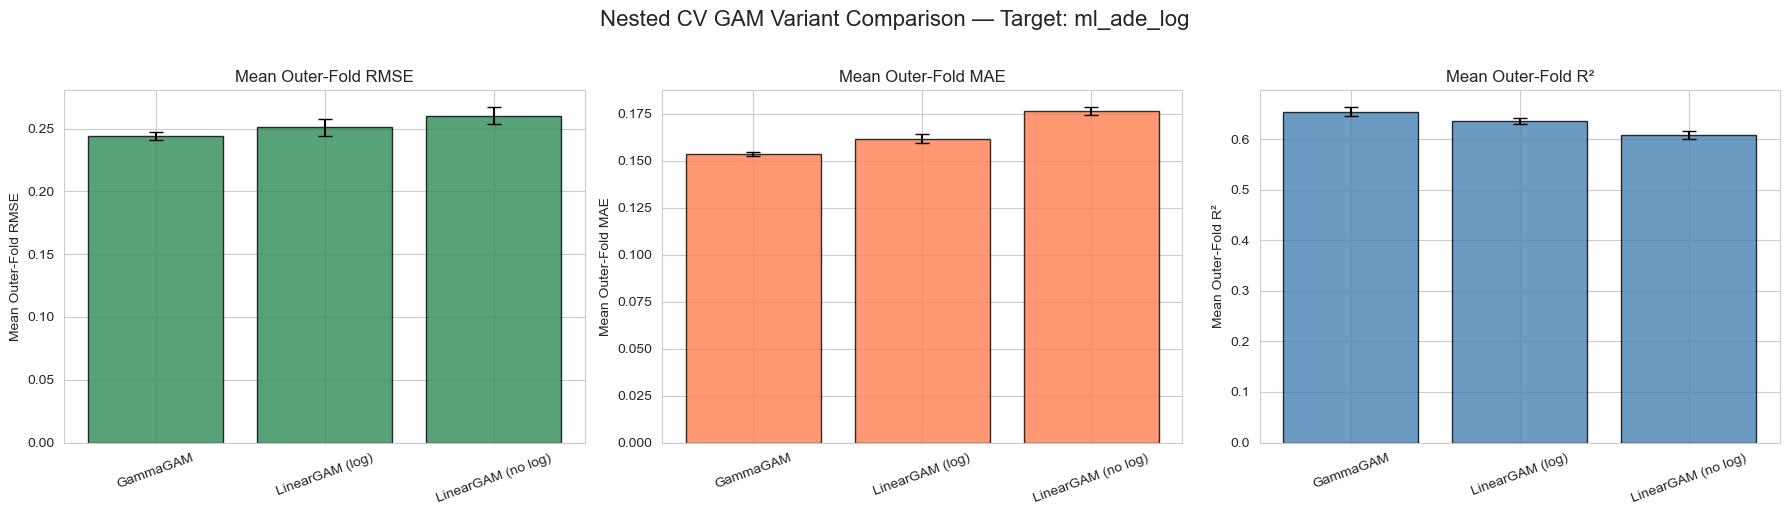

Nested variant comparison table saved to: ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/tables/nested_variant_comparison_ml_ade_log.csv
Nested variant comparison plot saved to:  ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/plots/nested_variant_comparison_ml_ade_log.png


In [26]:
# Each spec describes one candidate exportable GAM. All variants share the same rows
# and features; only model family and target mode are allowed to differ here.
variant_specs = [
    {
        "variant_model_id": "gam-linear-log",
        "variant_name": "LinearGAM (log)",
        "model_kind": "linear",
        "target_mode": "log",
        "y_values": y_log,
        "eligible": True,
        "skip_reason": None,
    },
    {
        "variant_model_id": "gam-linear",
        "variant_name": "LinearGAM (no log)",
        "model_kind": "linear",
        "target_mode": "raw",
        "y_values": y_raw,
        "eligible": True,
        "skip_reason": None,
    },
    {
        "variant_model_id": "gam-gamma",
        "variant_name": "GammaGAM",
        "model_kind": "gamma",
        "target_mode": "raw",
        "y_values": y_raw,
        "eligible": bool((y_raw > 0).all()),
        "skip_reason": (
            None if (y_raw > 0).all() else "raw target contains non-positive values"
        ),
    },
]

variant_results = []
n_samples = len(model_df)

# Run nested CV independently for each eligible variant and keep variant-specific
# artifacts separate until the comparison step chooses the winner.
for variant_idx, spec in enumerate(variant_specs, start=1):
    if not spec["eligible"]:
        variant_results.append(
            {
                "variant_model_id": spec["variant_model_id"],
                "variant_name": spec["variant_name"],
                "model_kind": spec["model_kind"],
                "target_mode": spec["target_mode"],
                "status": "skipped",
                "skip_reason": spec["skip_reason"],
            }
        )
        print(f"Skipping {spec['variant_name']}: {spec['skip_reason']}")
        continue

    artifact_dirs = get_artifact_dirs(spec["variant_model_id"])
    outer_cv = KFold(n_splits=k_outer_fold, shuffle=True, random_state=RANDOM_STATE)
    oof_pred = np.full(n_samples, np.nan, dtype=float)
    oof_fold = np.full(n_samples, -1, dtype=int)
    nested_rows = []

    for fold_idx, (outer_train_idx, outer_valid_idx) in enumerate(
        outer_cv.split(X, spec["y_values"]), start=1
    ):
        X_outer_train = X[outer_train_idx]
        X_outer_valid = X[outer_valid_idx]
        y_outer_train = spec["y_values"][outer_train_idx]
        y_outer_valid_raw = y_raw[outer_valid_idx]

        tuning_result = run_gam_optuna_tuning(
            X_outer_train,
            y_outer_train,
            model_kind=spec["model_kind"],
            target_mode=spec["target_mode"],
            seed=RANDOM_STATE + variant_idx * 100 + fold_idx,
            tuning_scope=f"outer_fold_{fold_idx}",
            variant_name=spec["variant_name"],
            discrete_indices=discrete_feature_indices,
        )

        scaler = StandardScaler()
        X_outer_train_scaled = scaler.fit_transform(X_outer_train)
        X_outer_valid_scaled = scaler.transform(X_outer_valid)
        outer_model = fit_gam_model(
            spec["model_kind"],
            X_outer_train_scaled,
            y_outer_train,
            tuning_result["best_params"],
            discrete_indices=discrete_feature_indices,
        )

        outer_pred = outer_model.predict(X_outer_valid_scaled)
        oof_pred[outer_valid_idx] = outer_pred
        oof_fold[outer_valid_idx] = fold_idx

        # Convert predictions back to the raw metric scale before computing the outer
        # fold score used to compare variants.
        outer_pred_orig = to_original_scale(outer_pred, target_mode=spec["target_mode"])
        outer_metrics = regression_metrics(y_outer_valid_raw, outer_pred_orig)

        row = {
            "variant_model_id": spec["variant_model_id"],
            "variant_name": spec["variant_name"],
            "outer_fold": fold_idx,
            "outer_rmse": outer_metrics["RMSE"],
            "outer_mae": outer_metrics["MAE"],
            "outer_r2": outer_metrics["R²"],
            "inner_best_cv_rmse": tuning_result["best_cv_rmse"],
        }
        row.update({f"best_{k}": v for k, v in tuning_result["best_params"].items()})
        nested_rows.append(row)

        print(
            f"{spec['variant_name']} | outer fold {fold_idx}/{k_outer_fold} | "
            f"RMSE={outer_metrics['RMSE']:.6f} | MAE={outer_metrics['MAE']:.6f} | R2={outer_metrics['R²']:.4f}"
        )

    if np.isnan(oof_pred).any():
        raise ValueError(
            f"OOF predictions contain NaN values for {spec['variant_name']}. Check CV splits and training flow."
        )

    nested_cv_df = pd.DataFrame(nested_rows)
    nested_summary = summarize_nested_cv(nested_cv_df)
    summary_lookup = nested_summary.set_index("metric")
    selection_metric_value = float(summary_lookup.loc["outer_rmse", "mean"])

    model_df_oof = build_oof_frame(
        model_df,
        row_ids=row_ids,
        oof_pred=oof_pred,
        oof_fold=oof_fold,
        target_orig=model_df[raw_target_col].to_numpy(),
        pred_scale_kwargs={"target_mode": spec["target_mode"]},
    )
    oof_prediction_cols = identity_cols + [
        "row_id",
        "oof_pred",
        "oof_pred_orig",
        "target_orig",
        "outer_fold",
    ]
    oof_predictions_df = model_df_oof[oof_prediction_cols]
    metrics_df = build_oof_metrics_df(
        spec["y_values"], oof_pred, target_mode=spec["target_mode"]
    )

    nested_path = artifact_dirs["tables_dir"] / f"nested_cv_optuna_{target_col}.csv"
    nested_summary_path = (
        artifact_dirs["tables_dir"] / f"nested_cv_optuna_summary_{target_col}.csv"
    )
    oof_path = artifact_dirs["tables_dir"] / f"oof_predictions_{target_col}.csv"
    metrics_path = artifact_dirs["tables_dir"] / f"metrics_oof_{target_col}.csv"
    model_data_path = (
        artifact_dirs["tables_dir"] / f"model_data_with_oof_{target_col}.csv"
    )

    nested_cv_df.to_csv(nested_path, index=False)
    nested_summary.to_csv(nested_summary_path, index=False)
    oof_predictions_df.to_csv(oof_path, index=False)
    metrics_df.to_csv(metrics_path, index=False)
    model_df_oof.to_csv(model_data_path, index=False)

    variant_manifest = build_run_manifest(
        model_id=spec["variant_model_id"],
        run_name=OUTPUT_RUN_NAME,
        target_col=target_col,
        feature_cols=feature_cols,
        save_dir=artifact_dirs["save_dir"],
        plots_dir=artifact_dirs["plots_dir"],
        tables_dir=artifact_dirs["tables_dir"],
        nested_resampling={
            "nested_cv_path": str(nested_path),
            "nested_cv_summary_path": str(nested_summary_path),
            "oof_predictions_path": str(oof_path),
            "oof_metrics_path": str(metrics_path),
            "model_data_with_oof_path": str(model_data_path),
        },
        final_model={},
        analysis={
            "poor_well_quantile": POOR_WELL_QUANTILE,
        },
        extra_manifest_fields={
            "raw_target_col": raw_target_col,
            "log_target_col": log_target_col,
            "variant_model_id": spec["variant_model_id"],
            "variant_name": spec["variant_name"],
            "model_kind": spec["model_kind"],
            "target_mode": spec["target_mode"],
            "variant_status": "completed",
            "selection_metric_name": "mean_outer_rmse",
            "selection_metric_value": selection_metric_value,
        },
    )
    manifest_path = write_manifest(
        variant_manifest, artifact_dirs["tables_dir"], target_col
    )

    print(f"{spec['variant_name']} nested CV saved to: {nested_path}")
    print(f"{spec['variant_name']} OOF metrics saved to: {metrics_path}")
    print(f"{spec['variant_name']} manifest saved to:    {manifest_path}")

    variant_results.append(
        {
            "variant_model_id": spec["variant_model_id"],
            "variant_name": spec["variant_name"],
            "model_kind": spec["model_kind"],
            "target_mode": spec["target_mode"],
            "status": "completed",
            "selection_metric_name": "mean_outer_rmse",
            "selection_metric_value": selection_metric_value,
            "outer_r2_mean": float(summary_lookup.loc["outer_r2", "mean"]),
            "outer_r2_std": float(summary_lookup.loc["outer_r2", "std"]),
            "outer_mae_mean": float(summary_lookup.loc["outer_mae", "mean"]),
            "outer_mae_std": float(summary_lookup.loc["outer_mae", "std"]),
            "outer_rmse_mean": float(summary_lookup.loc["outer_rmse", "mean"]),
            "outer_rmse_std": float(summary_lookup.loc["outer_rmse", "std"]),
            "nested_cv_path": str(nested_path),
            "nested_cv_summary_path": str(nested_summary_path),
            "oof_predictions_path": str(oof_path),
            "oof_metrics_path": str(metrics_path),
            "model_data_with_oof_path": str(model_data_path),
            "manifest_path": str(manifest_path),
        }
    )

completed_variants = [row for row in variant_results if row["status"] == "completed"]
if not completed_variants:
    raise ValueError("No eligible GAM variants completed nested CV.")

# Lowest mean outer-fold RMSE on the original scale is the single selection rule that
# determines which GAM variant graduates to the full-data refit.
selected_variant = min(completed_variants, key=lambda row: row["outer_rmse_mean"])
print("Selected GAM variant based on lowest mean outer-fold RMSE on original scale:")
print(selected_variant)

variant_comparison_df = (
    pd.DataFrame(completed_variants)[
        [
            "variant_model_id",
            "variant_name",
            "outer_rmse_mean",
            "outer_rmse_std",
            "outer_mae_mean",
            "outer_mae_std",
            "outer_r2_mean",
            "outer_r2_std",
        ]
    ]
    .sort_values("outer_rmse_mean")
    .reset_index(drop=True)
)
display(variant_comparison_df)

variant_comparison_path = TABLES_DIR / f"nested_variant_comparison_{target_col}.csv"
variant_comparison_df.to_csv(variant_comparison_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_specs = [
    ("outer_rmse_mean", "outer_rmse_std", "Mean Outer-Fold RMSE", "seagreen"),
    ("outer_mae_mean", "outer_mae_std", "Mean Outer-Fold MAE", "coral"),
    ("outer_r2_mean", "outer_r2_std", "Mean Outer-Fold R²", "steelblue"),
]
for ax, (mean_col, std_col, title, color) in zip(axes, metric_specs):
    ax.bar(
        variant_comparison_df["variant_name"],
        variant_comparison_df[mean_col],
        yerr=variant_comparison_df[std_col],
        color=color,
        edgecolor="black",
        alpha=0.8,
        capsize=5,
    )
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle(
    f"Nested CV GAM Variant Comparison — Target: {target_col}", fontsize=16, y=1.02
)
plt.tight_layout()
variant_comparison_plot_path = PLOTS_DIR / f"nested_variant_comparison_{target_col}.png"
plt.savefig(variant_comparison_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Nested variant comparison table saved to: {variant_comparison_path}")
print(f"Nested variant comparison plot saved to:  {variant_comparison_plot_path}")

## 5. Full-Data Retuning for the Winning GAM Variant
**Purpose:** Run track 2 of the workflow: after nested resampling has identified the GAM variant with the best generalization and established an unbiased estimate for its tuning procedure, rerun that same tuning procedure on all filtered rows, identify the best full-data hyperparameter configuration, and refit the final GAM on all available rows using that configuration.<br>
**Inputs:** selected nested-CV winner, full filtered feature matrix, matching target mode, and the same Optuna search space used in track 1.<br>
**Outputs:** full-data tuning trials, tuning summary JSON, fitted scaler, and a final GAM refit on all filtered rows with the best hyperparameter configuration found during the full-data retuning step.<br>
**How to Verify:** confirm the printed winner matches the lowest `outer_rmse_mean`, then confirm the saved tuning summary records the selected variant metadata and best CV RMSE, and finally confirm the final scaler/model fit happens after the full-data retuning result is available.


In [27]:
# Track 2 starts here: after track 1 selected the winning GAM variant and measured
# how the tuning procedure generalizes, rerun that same tuning procedure on all rows
# so the exported model can use every available sample when learning associations.
# Refit only the winning target mode/model family on all filtered rows. This keeps
# the exported GAM aligned with the same selection rule used during nested CV.
selected_variant_y = y_log if selected_variant["target_mode"] == "log" else y_raw

full_data_tuning = run_gam_optuna_tuning(
    X,
    selected_variant_y,
    model_kind=selected_variant["model_kind"],
    target_mode=selected_variant["target_mode"],
    seed=RANDOM_STATE + 1000,
    tuning_scope="full_data",
    variant_name=selected_variant["variant_name"],
    discrete_indices=discrete_feature_indices,
)
full_data_tuning_trials_df = full_data_tuning["trial_results_df"]
full_data_tuning_trials_path = (
    TABLES_DIR / f"full_data_tuning_optuna_trials_{target_col}.csv"
)
full_data_tuning_trials_df.to_csv(full_data_tuning_trials_path, index=False)

selected_variant_nested_summary = {
    "outer_rmse_mean": selected_variant["outer_rmse_mean"],
    "outer_rmse_std": selected_variant["outer_rmse_std"],
    "outer_mae_mean": selected_variant["outer_mae_mean"],
    "outer_mae_std": selected_variant["outer_mae_std"],
    "outer_r2_mean": selected_variant["outer_r2_mean"],
    "outer_r2_std": selected_variant["outer_r2_std"],
}

full_data_tuning_summary = {
    "model_id": MODEL_ID,
    "run_name": OUTPUT_RUN_NAME,
    "target_col": target_col,
    "raw_target_col": raw_target_col,
    "log_target_col": log_target_col,
    "selection_metric_name": "mean_outer_rmse",
    "selection_metric_value": selected_variant["selection_metric_value"],
    "variant_results": variant_results,
    "nested_variant_comparison_path": str(variant_comparison_path),
    "nested_variant_comparison_plot_path": str(variant_comparison_plot_path),
    "selected_variant_model_id": selected_variant["variant_model_id"],
    "selected_variant_manifest_path": selected_variant["manifest_path"],
    "selected_variant_name": selected_variant["variant_name"],
    "selected_variant_model_kind": selected_variant["model_kind"],
    "selected_variant_target_mode": selected_variant["target_mode"],
    "selected_variant_nested_summary": selected_variant_nested_summary,
    "selected_best_params": full_data_tuning["best_params"],
    "full_data_best_cv_rmse": full_data_tuning["best_cv_rmse"],
    "tuning_config": {
        "nfold": k_inner_fold,
        "n_trials": N_OPTUNA_TRIALS,
        "n_splines_range": [MIN_SPLINES, MAX_SPLINES],
        "spline_order_range": [MIN_SPLINE_ORDER, MAX_SPLINE_ORDER],
        "lam_range": [MIN_LAM, MAX_LAM],
        "random_state": RANDOM_STATE,
    },
}
full_data_tuning_summary_path = (
    TABLES_DIR / f"full_data_tuning_optuna_summary_{target_col}.json"
)
full_data_tuning_summary_path.write_text(json.dumps(full_data_tuning_summary, indent=2))

selected_y = selected_variant_y
# Fit one final scaler on all selected rows because the exported GAM expects scaled
# inputs identical to the data used during the full-data refit.
# The resulting model is a second fit on full data using the best hyperparameters found
# by the full-data retuning step above, not one of the models from nested resampling.
final_scaler = StandardScaler()
X_scaled_all = final_scaler.fit_transform(X)
final_model = fit_gam_model(
    selected_variant["model_kind"],
    X_scaled_all,
    selected_y,
    full_data_tuning["best_params"],
    discrete_indices=discrete_feature_indices,
)

print(
    "Selected GAM variant based on lowest mean outer-fold RMSE on original scale: "
    f"{selected_variant['variant_name']} ({selected_variant['variant_model_id']})"
)
print(f"- mean_outer_rmse={selected_variant['selection_metric_value']:.6f}")
print(f"- full_data_best_cv_rmse={full_data_tuning['best_cv_rmse']:.6f}")
print(f"Full-data tuning trials saved to: {full_data_tuning_trials_path}")
print(f"Full-data tuning summary saved to: {full_data_tuning_summary_path}")
print(
    "Final GAM model fitted on all data using the selected full-data-retuned variant."
)

GammaGAM | full_data tuning complete | best_cv_rmse=0.245763
Selected GAM variant based on lowest mean outer-fold RMSE on original scale: GammaGAM (gam-gamma)
- mean_outer_rmse=0.244367
- full_data_best_cv_rmse=0.245763
Full-data tuning trials saved to: ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/tables/full_data_tuning_optuna_trials_ml_ade_log.csv
Full-data tuning summary saved to: ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/tables/full_data_tuning_optuna_summary_ml_ade_log.json
Final GAM model fitted on all data using the selected full-data-retuned variant.


## 6. Export Artifacts and Run Manifest
**Purpose:** Persist the final selected GAM from track 2, copy the winning nested-CV diagnostics from track 1 into the canonical GAM run directory, and publish a manifest for downstream analysis.<br>
**Inputs:** final fitted GAM/scaler from the full-data refit, winning variant artifact paths from nested resampling, full-data tuning outputs, and run metadata.<br>
**Outputs:** saved model/scaler pickles, canonical nested-CV and OOF tables, and `run_manifest_<target>.json` for the selected GAM run.<br>
**How to Verify:** confirm the copied canonical tables match the winning variant paths from nested resampling, and confirm the final manifest points to the copied canonical files while the exported model/scaler come from the full-data refit.


In [28]:
# Copy the winning variant's diagnostics into the canonical GAM directory so downstream
# notebooks can load one stable manifest regardless of which variant won internally.
model_path = SAVE_DIR / f"gam_model_{target_col}.pkl"
with model_path.open("wb") as f:
    pickle.dump(final_model, f)

scaler_path = SAVE_DIR / f"gam_scaler_{target_col}.pkl"
with scaler_path.open("wb") as f:
    pickle.dump(final_scaler, f)

selected_nested_cv_path = TABLES_DIR / f"nested_cv_optuna_{target_col}.csv"
selected_nested_summary_path = TABLES_DIR / f"nested_cv_optuna_summary_{target_col}.csv"
selected_oof_path = TABLES_DIR / f"oof_predictions_{target_col}.csv"
selected_metrics_path = TABLES_DIR / f"metrics_oof_{target_col}.csv"
data_path = TABLES_DIR / f"model_data_with_oof_{target_col}.csv"

pd.read_csv(selected_variant["nested_cv_path"]).to_csv(
    selected_nested_cv_path, index=False
)
pd.read_csv(selected_variant["nested_cv_summary_path"]).to_csv(
    selected_nested_summary_path, index=False
)
pd.read_csv(selected_variant["oof_predictions_path"]).to_csv(
    selected_oof_path, index=False
)
pd.read_csv(selected_variant["oof_metrics_path"]).to_csv(
    selected_metrics_path, index=False
)
pd.read_csv(selected_variant["model_data_with_oof_path"]).to_csv(data_path, index=False)

# The manifest intentionally references the canonical copied files, not the variant
# scratch directory, because analysis notebooks load only this top-level GAM run.
manifest = build_run_manifest(
    model_id=MODEL_ID,
    run_name=OUTPUT_RUN_NAME,
    target_col=target_col,
    feature_cols=feature_cols,
    save_dir=SAVE_DIR,
    plots_dir=PLOTS_DIR,
    tables_dir=TABLES_DIR,
    nested_resampling={
        "nested_cv_path": str(selected_nested_cv_path),
        "nested_cv_summary_path": str(selected_nested_summary_path),
        "oof_predictions_path": str(selected_oof_path),
        "oof_metrics_path": str(selected_metrics_path),
        "model_data_with_oof_path": str(data_path),
    },
    final_model={
        "model_path": str(model_path),
        "scaler_path": str(scaler_path),
        "full_data_tuning_trials_path": str(full_data_tuning_trials_path),
        "full_data_tuning_summary_path": str(full_data_tuning_summary_path),
        "nested_variant_comparison_path": str(variant_comparison_path),
        "nested_variant_comparison_plot_path": str(variant_comparison_plot_path),
        "selected_variant_model_id": selected_variant["variant_model_id"],
        "selected_variant_manifest_path": selected_variant["manifest_path"],
        "selected_variant_name": selected_variant["variant_name"],
        "selected_variant_model_kind": selected_variant["model_kind"],
        "selected_variant_target_mode": selected_variant["target_mode"],
        "selected_variant_nested_summary": selected_variant_nested_summary,
        "selected_best_params": full_data_tuning["best_params"],
        "selected_full_data_best_cv_rmse": full_data_tuning["best_cv_rmse"],
        "exported_model_name": selected_variant["variant_name"],
        "exported_model_kind": selected_variant["model_kind"],
        "exported_model_target_mode": selected_variant["target_mode"],
        "exported_model_selection_metric_name": "mean_outer_rmse",
        "exported_model_selection_metric_value": selected_variant[
            "selection_metric_value"
        ],
    },
    analysis={
        "poor_well_quantile": POOR_WELL_QUANTILE,
    },
    extra_manifest_fields={
        "raw_target_col": raw_target_col,
        "log_target_col": log_target_col,
        "winning_variant_model_id": selected_variant["variant_model_id"],
        "winning_variant_name": selected_variant["variant_name"],
        "winning_variant_model_kind": selected_variant["model_kind"],
        "winning_variant_target_mode": selected_variant["target_mode"],
        "selection_metric_name": "mean_outer_rmse",
        "selection_metric_value": selected_variant["selection_metric_value"],
    },
)
manifest_path = write_manifest(manifest, TABLES_DIR, target_col)

print(f"Final GAM model saved to: {model_path}")
print(f"Final GAM scaler saved to: {scaler_path}")
print(f"Selected nested CV fold results copied to: {selected_nested_cv_path}")
print(f"Selected OOF metrics copied to:            {selected_metrics_path}")
print(f"Model data with OOF predictions saved to: {data_path}")
print(f"Run manifest saved to: {manifest_path}")
print("Exported model summary:")
print(f"- Name: {selected_variant['variant_name']}")
print(f"- Kind: {selected_variant['model_kind']}")
print(f"- Target mode: {selected_variant['target_mode']}")
print(
    f"- Selection metric: mean_outer_rmse={selected_variant['selection_metric_value']:.6f}"
)
print(f"- Full-data best_cv_rmse: {full_data_tuning['best_cv_rmse']:.6f}")

Final GAM model saved to: ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/gam_model_ml_ade_log.pkl
Final GAM scaler saved to: ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/gam_scaler_ml_ade_log.pkl
Selected nested CV fold results copied to: ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/tables/nested_cv_optuna_ml_ade_log.csv
Selected OOF metrics copied to:            ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/tables/metrics_oof_ml_ade_log.csv
Model data with OOF predictions saved to: ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/tables/model_data_with_oof_ml_ade_log.csv
Run manifest saved to: ../../results/interpretable_model/gam/sweep_large_30ep_1seed_MI_corrected/tables/run_manifest_ml_ade_log.json
Exported model summary:
- Name: GammaGAM
- Kind: gamma
- Target mode: raw
- Selection metric: mean_outer_rmse=0.244367
- Full-data best_cv_rmse: 0.245